## **Messungen**

In [1]:
import numpy as np

#Messungen zur Kopplungsfeder

g = 9.81 #Erdbeschleunigung

m_ges = 509.26e-3   #Gesamtmasse eines Pendels
m_ges_Fehler = 0.01e-3

d = (7.2 - 0.6)*10**(-2) # Auslenkung der Feder in m
d_Fehler = 4e-3 #TODO

a_Pendel = 0.6e-2 #Auslenkung des Pendels bei der Messung
a_Pendel_Fehler = 2e-3 #TODO

""" ---------------------------------------------------------------------------- """

#Messungen zu den Schwingungsfrequenzen der gekoppelten Pendel

T_eigen_a = 1350 / 100 /10 #Eigenperiodendauer des Pendels a in s
T_eigen_b = 1350 /100 /10 #Eigenperiodendauer des Pendels b in s
T_eigen_Fehler = 25 /100 /10

""" ---------------------------------------------------------------------------- """

L_1 = 42.6e-2  #Erste Koppungslänge in m, Bestimmung von D bei L_1
L_1_Fehler = 1e-3

T_gleich_1 = 1350 /100 /10 #Eigenperiodendauer der gleichphasigen Schwingung in s
T_gegen_1 = 1250 /100 /10 #Eigenperiodendauer der gegenphasigen Schwingung in s

T_gleich_Fehler_1 = 25 /100 /10
T_gegen_Fehler_1 = 25 /100 /10

T_s_1 = 8300 /100 /2 #TODO: Previous 8200
T_s_1_Fehler = 100 /100 /2

T_T_1 = 1350 /100 /10 #TODO: Previous 1400
T_T_1_Fehler = 100 /100 /10

""" ---------------------------------------------------------------------------- """

L_2 = 38.6e-2 #Zweite Koppungslänge in m
L_2_Fehler = 2e-3

T_gleich_2 = 1325 /100 /10 #Eigenperiodendauer der gleichphasigen Schwingung in s #TODO: Previous 1350
T_gegen_2 = 1250/ 100 / 10 #Eigenperiodendauer der gegenphasigen Schwingung in s

T_gleich_Fehler_2 = 25 /100 /10
T_gegen_Fehler_2 = 25 /100 /10

T_s_2 = 5650 /100 /1   #TODO: Previous: 5900
T_s_2_Fehler = 100 /100 /1

T_T_2 = 2600 /100 /20 #TODO: Previous 2800 / 100 / 21
T_T_2_Fehler =  100 /100 /20

""" ---------------------------------------------------------------------------- """

L_3 = 34.6e-2 #Dritte Koppungslänge in m
L_3_Fehler = 2e-3

T_gleich_3 = 2400 /100 /18 #Eigenperiodendauer der gleichphasigen Schwingung in s #TODO: Previous: 1350 / 100 /10
T_gegen_3 = 2300 / 100 /18 #Eigenperiodendauern der gegenphasigen Schwingung in s #TODO: Previous:1300 /100 /10

T_gleich_Fehler_3 = 25 /100 /18
T_gegen_Fehler_3 = 25  /100 /18

T_s = 8600 /100 /1 #Schwebung #TODO: Previous 8400
T_s_Fehler = 100 /100 /1

T_T = 2600 /100 /20 #Träger #TODO: Previous 4200 / 100 / 31
T_T_Fehler = 100 /100 /20



## **1. Federkonstante bestimmen**

In [2]:
from Skripte.Fehlerfortpflanzung import Gaußfehler
from IPython.display import display
import sympy as sp

D = (m_ges*g* a_Pendel ) / (d*L_1) #Berechnung der Federkonstanten

mgp, ap, dp, lp = sp.symbols("M_ges, a d, L_1")
expr = mgp * g *ap / (dp*lp)
display(expr)

D_Fehler = Gaußfehler(expr, np.array([mgp, ap, dp, lp]), np.array([m_ges, a_Pendel, d, L_1]), np.array([m_ges_Fehler, a_Pendel_Fehler, d_Fehler, L_1_Fehler]))


print(f"D = {D} +/- {D_Fehler} N/m")

9.81*M_ges*a/(L_1*d)

D = 1.0661204865556981 +/- 0.36120834925098977 N/m



## **2. Bestimmung der Schwerpunktslänge**

In [3]:

L_S_a = g * ( T_eigen_a / (2*np.pi))**2 #Berechungsformel für die Schwerpunktslänge (Länge eines mathematischen Pendls mit gleicher Frequenz)
L_S_b = g * ( T_eigen_b / (2*np.pi))**2

Tp = sp.Symbol("T_eigen")
expr = g * (Tp / (2*sp.pi))**2
display(expr)

L_S_a_Fehler = Gaußfehler(expr, np.array([Tp]), np.array([T_eigen_a]), np.array([T_eigen_Fehler]))
L_S_b_Fehler = Gaußfehler(expr, np.array([Tp]), np.array([T_eigen_b]), np.array([T_eigen_Fehler]))

print(f"\nSchwerpunktslänge des Pendels a: L_S = {L_S_a} +/- {L_S_a_Fehler} m")
print(f"Schwerpunktslänge des Pendels b: L_S = {L_S_b} +/- {L_S_b_Fehler} m")



2.4525*T_eigen**2/pi**2


Schwerpunktslänge des Pendels a: L_S = 0.452873394753964 +/- 0.016773088694591258 m
Schwerpunktslänge des Pendels b: L_S = 0.452873394753964 +/- 0.016773088694591258 m



## **3. Kopplungsgrade berechnen**

(-T_gegen**2 + T_gleich**2)/(T_gegen**2 + T_gleich**2)

2*T_S*T_T/(T_S**2 + T_T**2)

D*l**2/(D*l**2 + 9.81*L_s*M_ges)


Kopplungsgrad für L = 0.426 m aus den Periodendauern ist K = 0.07680945347119651 +/- 0.02709603670672708
Kopplungsgrad für L = 0.426 m aus der Schwebungsfrequenz ist K = 0.06499146642615088 +/- 0.004867135336091001
Kopplungsgrad für L = 0.426 m aus den Maßen ist K = 0.07877790916293022 +/- 0.024736657862860504


Kopplungsgrad für L = 0.386 m ist K = 0.058203051422113385 +/- 0.027402284893933416
Kopplungsgrad für L = 0.386 m aus der Schwebungsfrequenz ist K = 0.04599334990638522 +/- 0.0019452287353571714
Kopplungsgrad für L = 0.386 m aus den Maßen ist K = 0.0656034591366008 +/- 0.020902086440399828


Kopplungsgrad für L = 0.346 m ist K = 0.042533936651583774 +/- 0.015027808794257696
Kopplungsgrad für L = 0.346 m aus der Schwebungsfrequenz ist K = 0.030225651520947756 +/- 0.0012139365122236657
Kopplungsgrad für L = 0.346 m aus den Maßen ist K = 0.05339980781072496 +/- 0.017238005166833152



Text(0.5, 1.0, 'Verhältnis von Kopplungslänge zu Kopplungsgrad')

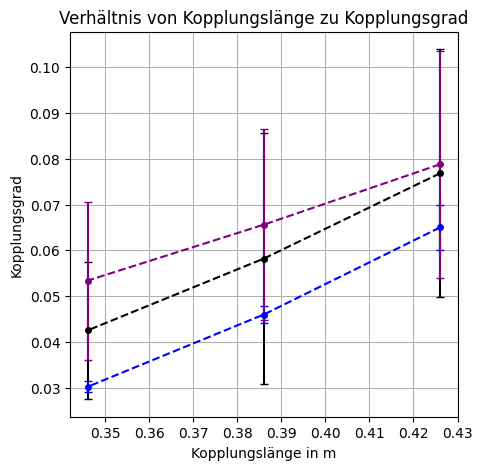

In [4]:
import matplotlib.pyplot as plt


Tgl, Tgg = sp.symbols("T_gleich, T_gegen")
expr = (Tgl**2 - Tgg**2) / (Tgl**2 + Tgg**2)
Variablen = np.array([Tgl, Tgg])
display(expr)

print("")

Tsp, Ttp = sp.symbols("T_S, T_T")
expr2 = 2*(Ttp*Tsp) / (Tsp**2 + Ttp**2)
Variablen_2 = np.array([Tsp, Ttp])
display(expr2)

Dp, lp, mp, Lp = sp.symbols("D, l, M_ges, L_s")
expr3 = (Dp*lp**2) / (mp*g*Lp + Dp*lp**2)
Variablen_3 = np.array([Dp, lp, mp, Lp])
display(expr3)

""" ---------------------------------------------------------------------------- """

#Kopplungsgrad für L_1:

K_1 = (T_gleich_1**2 - T_gegen_1**2) / (T_gleich_1**2 + T_gegen_1**2)
K_1_Fehler = Gaußfehler(expr, Variablen, np.array([T_gleich_1, T_gegen_1]), np.array([T_gleich_Fehler_1, T_gegen_Fehler_1]))

print(f"\nKopplungsgrad für L = {L_1} m aus den Periodendauern ist K = {K_1} +/- {K_1_Fehler}")

K_1_S = 2*(T_s_1*T_T_1) / (T_s_1**2 + T_T_1**2)
K_1_S_Fehler = Gaußfehler(expr2, Variablen_2, np.array([T_s_1, T_T_1]), np.array([T_s_1_Fehler, T_T_1_Fehler]))

print(f"Kopplungsgrad für L = {L_1} m aus der Schwebungsfrequenz ist K = {K_1_S} +/- {K_1_S_Fehler}")

K_1_M = (D*L_1**2) / (m_ges*g*L_S_a + D*L_1**2)
K_1_M_Fehler = Gaußfehler(expr3, Variablen_3, np.array([D, L_1, m_ges, L_S_a]), np.array([D_Fehler, L_1_Fehler, m_ges_Fehler, L_S_a_Fehler]))

print(f"Kopplungsgrad für L = {L_1} m aus den Maßen ist K = {K_1_M} +/- {K_1_M_Fehler}\n")

""" ---------------------------------------------------------------------------- """

#Kopplungsgrad für L_2:

K_2 = (T_gleich_2**2 - T_gegen_2**2) / (T_gleich_2**2 + T_gegen_2**2)
K_2_Fehler = Gaußfehler(expr, Variablen, np.array([T_gleich_2, T_gegen_2]), np.array([T_gleich_Fehler_2, T_gegen_Fehler_2]))

print(f"\nKopplungsgrad für L = {L_2} m ist K = {K_2} +/- {K_2_Fehler}")

K_2_S = 2*(T_s_2*T_T_2) / (T_s_2**2 + T_T_2**2)
K_2_S_Fehler = Gaußfehler(expr2, Variablen_2, np.array([T_s_2, T_T_2]), np.array([T_s_2_Fehler, T_T_2_Fehler]))

print(f"Kopplungsgrad für L = {L_2} m aus der Schwebungsfrequenz ist K = {K_2_S} +/- {K_2_S_Fehler}")

K_2_M = (D*L_2**2) / (m_ges*g*L_S_a + D*L_2**2)
K_2_M_Fehler = Gaußfehler(expr3, Variablen_3, np.array([D, L_2, m_ges, L_S_a]), np.array([D_Fehler, L_2_Fehler, m_ges_Fehler, L_S_a_Fehler]))

print(f"Kopplungsgrad für L = {L_2} m aus den Maßen ist K = {K_2_M} +/- {K_2_M_Fehler}\n")

""" ---------------------------------------------------------------------------- """

#Kopplungsgrad für L_3:

K_3 = (T_gleich_3**2 - T_gegen_3**2) / (T_gleich_3**2 + T_gegen_3**2)
K_3_Fehler = Gaußfehler(expr, Variablen, np.array([T_gleich_3, T_gegen_3]), np.array([T_gleich_Fehler_3, T_gegen_Fehler_3]))

print(f"\nKopplungsgrad für L = {L_3} m ist K = {K_3} +/- {K_3_Fehler}")


""" ---------------------------------------------------------------------------- """

#Kopplungsgrad für L_3 (Aus Schwebungsfrequenz)

K_3_S = 2*(T_s*T_T) / (T_s**2 + T_T**2)
K_3_S_Fehler = Gaußfehler(expr2, Variablen_2, np.array([T_s, T_T]), np.array([T_s_Fehler, T_T_Fehler]))

print(f"Kopplungsgrad für L = {L_3} m aus der Schwebungsfrequenz ist K = {K_3_S} +/- {K_3_S_Fehler}")

K_3_M = (D*L_3**2) / (m_ges*g*L_S_a + D*L_3**2)
K_3_M_Fehler = Gaußfehler(expr3, Variablen_3, np.array([D, L_3, m_ges, L_S_a]), np.array([D_Fehler, L_3_Fehler, m_ges_Fehler, L_S_a_Fehler]))

print(f"Kopplungsgrad für L = {L_3} m aus den Maßen ist K = {K_3_M} +/- {K_3_M_Fehler}\n")


""" ---------------------------------------------------------------------------- """

#Plot
fig, ax1 = plt.subplots(1,1, figsize = (5,5))

ax1.errorbar(np.array([L_1, L_2, L_3]), np.array([K_1, K_2, K_3]), yerr = np.array([K_1_Fehler, K_2_Fehler, K_3_Fehler]), fmt = "--o", label = "Datensatz", color = "black", markersize  = 4 , capsize = 3, ecolor = "black")

ax1.errorbar(np.array([L_1, L_2, L_3]), np.array([K_1_S, K_2_S, K_3_S]), yerr = np.array([K_1_S_Fehler, K_2_S_Fehler, K_3_S_Fehler]), fmt = "--o", label = "Datensatz", color = "blue", markersize  = 4 , capsize = 3, ecolor = "blue")

ax1.errorbar(np.array([L_1, L_2, L_3]), np.array([K_1_M, K_2_M, K_3_M]), yerr = np.array([K_1_M_Fehler, K_2_M_Fehler, K_3_M_Fehler]), fmt = "--o", label = "Datensatz", color = "purple", markersize  = 4 , capsize = 3, ecolor = "purple")


ax1.set_xlabel("Kopplungslänge in m")
ax1.set_ylabel("Kopplungsgrad")
ax1.grid(True)
ax1.set_title("Verhältnis von Kopplungslänge zu Kopplungsgrad")


## **4. Berechung des Trägheitsmoments**

In [5]:

Dp, Lp, Tk1, Tk2 = sp.symbols("D, L, T_1, T_2")

expr = (2* Dp * Lp**2) / (4* sp.pi**2 * (1/(Tk2**2) - 1/(Tk1**2)))
display(expr)
Variablen = np.array([Dp, Lp, Tk1, Tk2])

""" ---------------------------------------------------------------------------- """

#Berechnung für die erste Kopplungslänge

I_1 = (D*L_1**2) / (2*np.pi**2*(1/(T_gegen_1**2) - 1/(T_gleich_1**2)))

I_1_Fehler = Gaußfehler(expr, Variablen, np.array([D, L_1, T_gleich_1, T_gegen_1]), np.array([D_Fehler, L_1_Fehler, T_gleich_Fehler_1, T_gegen_Fehler_1]))

print(f"\nTrägheitmoment für Kopplungslänge L = {L_1} m : I = {I_1} +/- {I_1_Fehler} kg*m**2")


""" ---------------------------------------------------------------------------- """


#Berechnung für die zweite Kopplungslänge

I_2 = (D*L_2**2) / (2*np.pi**2*(1/(T_gegen_2**2) - 1/(T_gleich_2**2)))

I_2_Fehler = Gaußfehler(expr, Variablen, np.array([D, L_2, T_gleich_2, T_gegen_2]), np.array([D_Fehler, L_2_Fehler, T_gleich_Fehler_2, T_gegen_Fehler_2]))

print(f"\nTrägheitmoment für Kopplungslänge L = {L_2} m : I = {I_2} +/- {I_2_Fehler} kg*m**2")


""" ---------------------------------------------------------------------------- """


#Berechnung für die dritte Kopplungslänge

I_3 = (D*L_3**2) / (2*np.pi**2*(1/(T_gegen_3**2) - 1/(T_gleich_3**2)))

I_3_Fehler = Gaußfehler(expr, Variablen, np.array([D, L_3, T_gleich_3, T_gegen_3]), np.array([D_Fehler, L_3_Fehler, T_gleich_Fehler_3, T_gegen_Fehler_3]))

from Skripte.Fehlerfortpflanzung import VisualGaußfehler

display(VisualGaußfehler(expr, Variablen))

print(f"\nTrägheitmoment für Kopplungslänge L = {L_3} m : I = {I_3} +/- {I_3_Fehler} kg*m**2")


D*L**2/(2*pi**2*(T_2**(-2) - 1/T_1**2))


Trägheitmoment für Kopplungslänge L = 0.426 m : I = 0.10735195578593079 +/- 0.0529157392802909 kg*m**2

Trägheitmoment für Kopplungslänge L = 0.386 m : I = 0.11430479337013283 +/- 0.06668309246143382 kg*m**2


sqrt(D**2*Delta_L**2*L**2/(pi**4*(T_2**(-2) - 1/T_1**2)**2) + D**2*Delta_T_1**2*L**4/(pi**4*T_1**6*(T_2**(-2) - 1/T_1**2)**4) + D**2*Delta_T_2**2*L**4/(pi**4*T_2**6*(T_2**(-2) - 1/T_1**2)**4) + Delta_D**2*L**4/(4*pi**4*(T_2**(-2) - 1/T_1**2)**2))


Trägheitmoment für Kopplungslänge L = 0.346 m : I = 0.1293790722781938 +/- 0.06349950310167561 kg*m**2
